In [1]:
import pandas as pd

### 1. Inicialização dos Dados

Nesta seção, vamos carregar os dados de telemetria de um arquivo CSV pré-existente (`telemetry_data_com_anomalias.csv`).

In [2]:
import pandas as pd

# Carregando o DataFrame de telemetria do arquivo CSV
file_path = 'telemetry_data_com_anomalias.csv'
url = 'https://raw.githubusercontent.com/Miguelgonn/Miguelgonn/refs/heads/main/telemetry_data_com_anomalias.csv'
telemetry_df_anomalies = pd.read_csv(url)

# Convertendo a coluna 'timestamp' para o tipo datetime
telemetry_df_anomalies['timestamp'] = pd.to_datetime(telemetry_df_anomalies['timestamp'])

print(f"DataFrame de telemetria carregado com sucesso de '{file_path}'.")
print(telemetry_df_anomalies.head())

DataFrame de telemetria carregado com sucesso de 'telemetry_data_com_anomalias.csv'.
            timestamp  internal_temp_c  external_temp_c  battery_voltage_v  \
0 2023-01-01 00:00:00        28.951161        21.002828          24.314428   
1 2023-01-01 00:01:00        24.179235         3.946608          22.484710   
2 2023-01-01 00:02:00        19.806908         1.157716          22.447312   
3 2023-01-01 00:03:00        29.031255         6.946203          23.652812   
4 2023-01-01 00:04:00        29.028977        32.010286          24.623470   

   battery_current_a  battery_soc_percent  battery_capacity_ah  power_load_kw  \
0           2.708133                   79           117.407317       0.503198   
1           3.002521                   76           115.486437       1.274441   
2           2.101565                   96           101.172155       1.682797   
3           3.302036                   96           109.271211       1.044739   
4           0.958249                   75

### 2. Definição das Condições de Lançamento

Nesta seção, vamos estabelecer as regras ou condições que, se violadas, resultarão em uma decisão de 'Abort'. Cada condição representa um limite operacional crítico ou uma anomalia nos dados de telemetria. Serão consideradas diversas variáveis, como temperaturas, carga da bateria, pressão do tanque e status dos módulos críticos.

In [3]:
# Define as condições que levariam a uma decisão de 'Abort'
# Cada condição é uma Série booleana que identifica as linhas que violam os limites de segurança ou operacionais.
conditions = [
    (telemetry_df_anomalies['internal_temp_c'] >= 35) | (telemetry_df_anomalies['external_temp_c'] < 0), # Anomalias de temperatura interna ou externa
    (telemetry_df_anomalies['battery_soc_percent'] < 75) & (telemetry_df_anomalies['estimated_autonomy_min'] < 90), # Baixa carga da bateria e autonomia insuficiente
    (telemetry_df_anomalies['tank_pressure_bar'] < 160) | (telemetry_df_anomalies['tank_pressure_bar'] > 190), # Pressão do tanque fora dos limites operacionais seguros
    # Condição combinada para status de sistemas críticos (integridade estrutural, módulos críticos, link de telemetria)
    (telemetry_df_anomalies['structural_integrity'] != 'OK') |
    (telemetry_df_anomalies['critical_modules_status'] != 'Operational') |
    (telemetry_df_anomalies['telemetry_link_status'] != 'Stable')
]

# Inicializa uma nova coluna 'launch_decision' com o valor padrão 'Launch'
telemetry_df_anomalies['launch_decision'] = 'Launch'

# Itera por cada condição definida
# Se uma linha atender a qualquer uma das condições de 'aborto', define sua 'launch_decision' como 'Abort'
for condition in conditions:
    telemetry_df_anomalies.loc[condition, 'launch_decision'] = 'Abort'

print("As decisões de lançamento foram calculadas com base nas condições especificadas.")
# Exibe o timestamp e a decisão de lançamento recém-calculada para as primeiras linhas
print(telemetry_df_anomalies[['timestamp', 'launch_decision']].head())

# Calcula e imprime a contagem das decisões 'Launch' e 'Abort'
launch_counts = telemetry_df_anomalies['launch_decision'].value_counts()
print("\nNúmero de decisões de Launch e Abort:")
print(launch_counts)
percentuais = telemetry_df_anomalies["launch_decision"].value_counts(normalize=True) * 100
print("\nPercentuais de Launch e Abort:")
print(percentuais)

As decisões de lançamento foram calculadas com base nas condições especificadas.
            timestamp launch_decision
0 2023-01-01 00:00:00           Abort
1 2023-01-01 00:01:00          Launch
2 2023-01-01 00:02:00          Launch
3 2023-01-01 00:03:00          Launch
4 2023-01-01 00:04:00           Abort

Número de decisões de Launch e Abort:
launch_decision
Abort     263
Launch    237
Name: count, dtype: int64

Percentuais de Launch e Abort:
launch_decision
Abort     52.6
Launch    47.4
Name: proportion, dtype: float64


####2.2 - A decisão de 'Abort' é acionada se qualquer uma das seguintes condições for verdadeira:

1.  **Condições de Temperatura:**
    *   A temperatura interna (`internal_temp_c`) é igual ou superior a 35°C, **OU**
    *   A temperatura externa (`external_temp_c`) é inferior a 0°C.

2.  **Condições da Bateria e Autonomia:**
    *   A porcentagem de carga da bateria (`battery_soc_percent`) é inferior a 75%, **E**
    *   A autonomia estimada (`estimated_autonomy_min`) é inferior a 90 minutos.

3.  **Condições de Pressão do Tanque:**
    *   A pressão do tanque (`tank_pressure_bar`) é inferior a 160 bar, **OU**
    *   A pressão do tanque (`tank_pressure_bar`) é superior a 190 bar.

4.  **Condições dos Sistemas Críticos:**
    *   A integridade estrutural (`structural_integrity`) **NÃO** é 'OK', **OU**
    *   O status dos módulos críticos (`critical_modules_status`) **NÃO** é 'Operational', **OU**
    *   O status do link de telemetria (`telemetry_link_status`) **NÃO** é 'Stable'.

####2.3 - Geração de Gráfico de Decisão

Nesta etapa, foi realizada a visualização da distribuição das decisões de lançamento a partir dos dados de telemetria analisados. Para isso, foram utilizadas as bibliotecas Matplotlib e Seaborn, amplamente empregadas na análise de dados em Python.Inicialmente, os dados foram agregados para contabilizar a quantidade de ocorrências de cada decisão possível (“Launch” e “Abort”). Em seguida, foi construído um gráfico de barras que permite comparar visualmente a frequência de cada resultado. Essa representação gráfica facilita a interpretação dos dados, tornando mais evidente qual decisão é predominante no conjunto analisado. Dessa forma, é possível identificar rapidamente tendências operacionais, como a predominância de abortamentos ou condições favoráveis à decolagem. Além disso, a visualização contribui para validar os resultados obtidos pelas análises anteriores, servindo como apoio à tomada de decisão e à compreensão do comportamento geral do sistema.

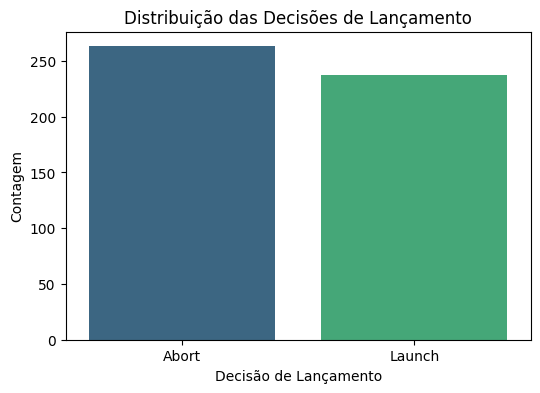

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando o gráfico de barras para as decisões de lançamento
plt.figure(figsize=(6, 4))
sns.barplot(x=launch_counts.index, y=launch_counts.values, palette='viridis', hue=launch_counts.index, legend=False)

plt.title('Distribuição das Decisões de Lançamento')
plt.xlabel('Decisão de Lançamento')
plt.ylabel('Contagem')
plt.show()

### 3. Implementação de Modelo de IA para Decisão de Lançamento

Implementamos um modelo de Machine Learning para prever a decisão de lançamento ('Launch' ou 'Abort') com base nas características da telemetria. Usamos um modelo de classificação como o `RandomForestClassifier`.

#### 3.1 Preparação dos Dados para o Modelo de IA

Primeiro, precisamos preparar os dados. Isso inclui selecionar as colunas que serão usadas como *features* (variáveis de entrada) e a coluna *target* (a decisão que queremos prever). Também será necessário converter variáveis categóricas em um formato numérico que o modelo possa entender.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Definir as features (X) e o target (y)
# Excluir 'timestamp' e a coluna original 'launch_decision' (se já foi modificada para o treinamento) e 'anomalia_inserida'
features = telemetry_df_anomalies.drop(columns=['timestamp', 'launch_decision', 'anomalia_inserida'])
target = telemetry_df_anomalies['launch_decision']

# Identificar colunas categóricas para encoding
categorical_features = ['structural_integrity', 'critical_modules_status', 'telemetry_link_status']

# Aplicar One-Hot Encoding para as features categóricas
features = pd.get_dummies(features, columns=categorical_features, drop_first=True)

# Converter a variável target para numérica (0 para Abort, 1 para Launch)
le = LabelEncoder()
target_encoded = le.fit_transform(target)

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(features, target_encoded, test_size=0.3, random_state=42)

print("Dados preparados para o treinamento do modelo.")
print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Colunas das features: {X_train.columns.tolist()}")

Dados preparados para o treinamento do modelo.
Formato de X_train: (350, 14)
Formato de y_train: (350,)
Colunas das features: ['internal_temp_c', 'external_temp_c', 'battery_voltage_v', 'battery_current_a', 'battery_soc_percent', 'battery_capacity_ah', 'power_load_kw', 'energy_loss_percent', 'tank_pressure_bar', 'estimated_autonomy_min', 'energy_available_kwh', 'structural_integrity_OK', 'critical_modules_status_Operational', 'telemetry_link_status_Unstable']


#### 3.2 Treinamento do Modelo de Classificação

Agora vamos treinar um `RandomForestClassifier` com os dados de treino.

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar o modelo RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinar o modelo
model.fit(X_train, y_train)

print("Modelo RandomForestClassifier treinado com sucesso.")

Modelo RandomForestClassifier treinado com sucesso.


#### 3.3 Avaliação do Modelo

Após o treinamento, é importante avaliar o desempenho do modelo nos dados de teste para entender o quão bem ele generaliza.

Acurácia do modelo: 0.9800

Relatório de Classificação:
              precision    recall  f1-score   support

       Abort       0.99      0.98      0.98        83
      Launch       0.97      0.99      0.98        67

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150


Matriz de Confusão:
[[81  2]
 [ 1 66]]


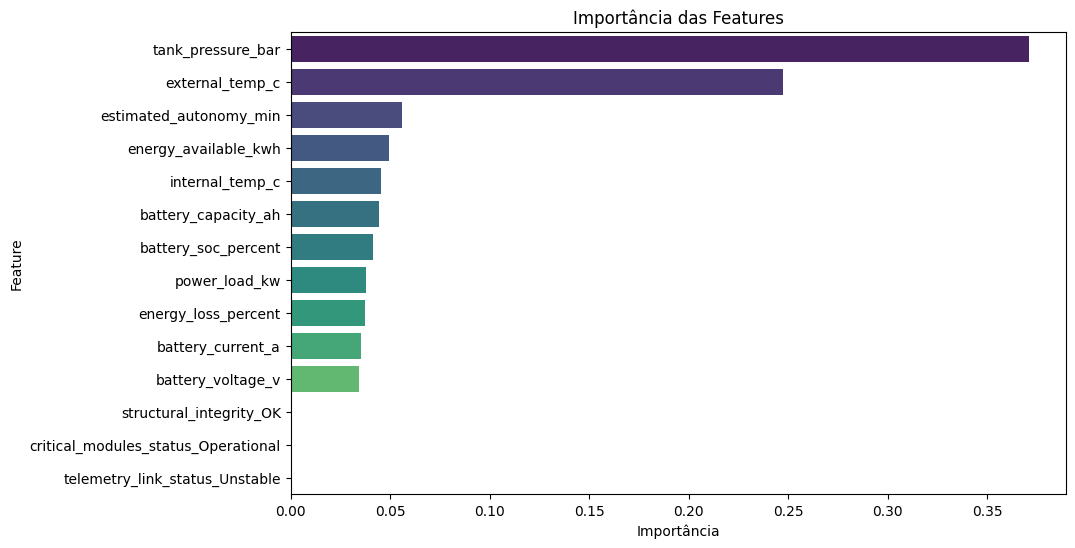

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar a acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.4f}")

# Exibir o relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Exibir a matriz de confusão
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

# Visualizar a importância das features
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis', hue=feature_importances.index, legend=False)
plt.title('Importância das Features')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

#### 3.4 Predição com o Modelo de IA

Agora que o modelo está treinado e avaliado, usaremos ele para prever as decisões de lançamento em novos dados ou no conjunto completo de telemetria.

In [8]:
# Fazer previsões para o DataFrame original (ou novos dados)
# Certifique-se de que os novos dados tenham as mesmas colunas e o mesmo pré-processamento que os dados de treinamento.

# Recriar as features para o dataset completo, aplicando o mesmo One-Hot Encoding
features_full = telemetry_df_anomalies.drop(columns=['timestamp', 'launch_decision', 'anomalia_inserida'])
features_full = pd.get_dummies(features_full, columns=categorical_features, drop_first=True)

# Garantir que as colunas sejam as mesmas que as do treino (pode haver colunas ausentes se o dataset de teste for diferente)
missing_cols = set(X_train.columns) - set(features_full.columns)
for c in missing_cols:
    features_full[c] = 0
# Garantir a ordem das colunas
features_full = features_full[X_train.columns]

# Fazer as previsões
predictions_encoded = model.predict(features_full)

# Converter as previsões de volta para as labels originais ('Launch'/'Abort')
telemetry_df_anomalies['launch_decision_ia'] = le.inverse_transform(predictions_encoded)

print("Decisões de lançamento baseadas no modelo de IA adicionadas ao DataFrame.")
print(telemetry_df_anomalies[['timestamp', 'launch_decision', 'launch_decision_ia']].head())

Decisões de lançamento baseadas no modelo de IA adicionadas ao DataFrame.
            timestamp launch_decision launch_decision_ia
0 2023-01-01 00:00:00           Abort              Abort
1 2023-01-01 00:01:00          Launch             Launch
2 2023-01-01 00:02:00          Launch             Launch
3 2023-01-01 00:03:00          Launch             Launch
4 2023-01-01 00:04:00           Abort              Abort


Este código implementa um modelo de IA básico para tomar a decisão de lançamento. Você pode experimentar com diferentes modelos, ajustar os parâmetros (hiperparâmetros) e adicionar mais engenharia de features para melhorar o desempenho do modelo.


####3.5 Interpretação das Decisões de Lançamento

Para o usuário final, as decisões de lançamento (seja as geradas por regras ou pelo modelo de IA) podem ser interpretadas da seguinte forma:

*   **`Launch`**: Indica que todas as condições operacionais e de segurança foram atendidas. Não há anomalias críticas detectadas e a operação (neste caso, o lançamento) pode prosseguir conforme o planejado.

*   **`Abort`**: Sinaliza uma ou mais violações de condições críticas de segurança ou operacionais. A operação **não deve prosseguir** e precisa ser interrompida imediatamente para evitar riscos ou falhas. Esta é a decisão de maior prioridade em termos de segurança.

*   **`Hold`**: Esta decisão, geralmente derivada dos dados brutos ou de um modelo de IA treinado com eles, sugere que há desvios ou condições que não são ideais, mas que *não são necessariamente críticas* o suficiente para um `Abort` imediato. Uma decisão de 'Hold' implica que a operação deve ser **pausada** para uma análise mais aprofundada, verificação manual ou correção de problemas menores antes que uma decisão final de `Launch` ou `Abort` possa ser tomada. Não é um 'Abort' imediato, mas exige atenção antes de qualquer prosseguimento.

####3.6 Comparação entre Decisão por Regras e Decisão por IA

Vamos gerar uma matriz de contingência (ou tabela cruzada) para visualizar a relação entre a `launch_decision` (gerada pelas regras definidas) e a `launch_decision_ia` (predita pelo modelo de IA). Isso nos ajuda a entender a concordância e discordância entre os dois métodos.

Matriz de Comparação entre Decisão por Regras e Decisão por IA:
launch_decision_ia  Abort  Launch  All
launch_decision                       
Abort                 261       2  263
Launch                  1     236  237
All                   262     238  500


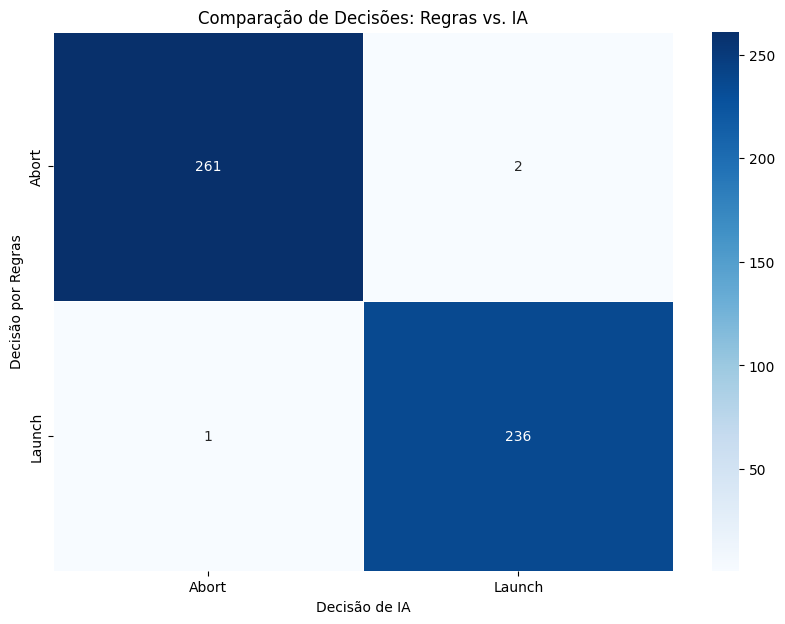

In [9]:
comparison_matrix = pd.crosstab(telemetry_df_anomalies['launch_decision'], telemetry_df_anomalies['launch_decision_ia'], margins=True)

print("Matriz de Comparação entre Decisão por Regras e Decisão por IA:")
print(comparison_matrix)

plt.figure(figsize=(10, 7))
sns.heatmap(comparison_matrix.iloc[:-1, :-1], annot=True, fmt="d", cmap="Blues", linewidths=.5)
plt.title('Comparação de Decisões: Regras vs. IA')
plt.xlabel('Decisão de IA')
plt.ylabel('Decisão por Regras')
plt.show()


###4. Calculo de eficiência energética

Para a análise energética, inicialmente foi calculada a energia disponível da nave em kWh, utilizando a relação entre tensão da bateria (V), capacidade (Ah) e nível de carga (%). Essa etapa permite estimar a quantidade total de energia armazenada no sistema. Em seguida, foi considerada a perda energética do sistema, representada pelo percentual de perdas (energy_loss_percent). A partir disso, foi calculada a energia útil disponível, ou seja, a quantidade de energia efetivamente aproveitável após a consideração das perdas operacionais. A eficiência energética foi então definida como a razão entre a energia útil e a energia total disponível, expressa em percentual. Esse indicador permite avaliar o desempenho do sistema energético da nave, indicando o quanto da energia armazenada é efetivamente convertida em trabalho útil. Valores mais baixos de eficiência podem indicar problemas como perdas térmicas, sobrecarga dos sistemas ou baixa performance dos componentes energéticos, o que pode impactar diretamente a viabilidade da decolagem.

In [10]:
# cálculo da energia útil (descontando perdas)
telemetry_df_anomalies['energia_util_kwh'] = telemetry_df_anomalies['energy_available_kwh'] * (1 - telemetry_df_anomalies['energy_loss_percent'] / 100)

# cálculo da eficiência energética (%)
telemetry_df_anomalies['eficiencia_energetica_percent'] = (telemetry_df_anomalies['energia_util_kwh'] / telemetry_df_anomalies['energy_available_kwh']) * 100

print("Eficiência energética calculada com sucesso.")
print(telemetry_df_anomalies[['energy_available_kwh', 'energia_util_kwh', 'eficiencia_energetica_percent']].head())

Eficiência energética calculada com sucesso.
   energy_available_kwh  energia_util_kwh  eficiencia_energetica_percent
0              2.255206          2.166893                      96.084013
1              1.973476          1.939739                      98.290482
2              2.180201          2.133507                      97.858259
3              2.481189          2.411171                      97.178065
4              2.135383          2.113891                      98.993500


In [11]:
media_eficiencia = telemetry_df_anomalies['eficiencia_energetica_percent'].mean()

print(f"Eficiência média do sistema: {media_eficiencia:.2f}%")

Eficiência média do sistema: 96.93%


In [12]:
if media_eficiencia >= 85:
    nivel = "alto"
    viabilidade = "suficiente"
elif media_eficiencia >= 60:
    nivel = "moderado"
    viabilidade = "aceitável"
else:
    nivel = "baixo"
    viabilidade = "insuficiente"

texto = f"A eficiência média de {media_eficiencia:.2f}% indica que o sistema apresenta um nível {nivel} de aproveitamento energético, sendo {viabilidade} para suportar a decolagem."

print(texto)

A eficiência média de 96.93% indica que o sistema apresenta um nível alto de aproveitamento energético, sendo suficiente para suportar a decolagem.


### 5. Análise assistida por IA

Para realizar a análise assistidda por IA, utilizamos o seguinte prompt no CHAT GPT:

Analise os dados de uma telemetria de uma nave espacial contendo os parâmetros que estão no arquivo que enviei (/content/telemetry_data_com_anomalias.csv). Essa analise precisa conter:
- Possíveisl riscos
- Padrões críticos
- Condições que levariam ao abortamento da missão

E, como resposta, obtivemos:

🤖 🔸 Resposta da IA (Análise)

A análise dos dados de telemetria revela que o sistema apresenta variações operacionais que podem impactar diretamente a segurança e a viabilidade da decolagem. A presença de anomalias em diferentes parâmetros indica a necessidade de monitoramento contínuo e tomada de decisão automatizada.

⚠️ Possíveis riscos

Os principais riscos identificados nos dados estão associados a:

- Variações de temperatura fora da faixa ideal, indicando possíveis falhas de controle térmico ou sobrecarga dos sistemas;
- Níveis reduzidos de energia (battery_soc_percent), que comprometem a autonomia da nave durante fases críticas da missão;
- Perdas energéticas elevadas (energy_loss_percent), reduzindo a eficiência do sistema e podendo causar falhas operacionais;
- Integridade estrutural comprometida (valores 0), representando risco crítico imediato à segurança da nave;
- Status irregular de módulos críticos, indicando possíveis falhas em subsistemas essenciais.

Esses riscos podem ocorrer de forma isolada ou combinada, aumentando significativamente a probabilidade de falha.

📊 Padrões críticos identificados

A análise dos dados evidencia alguns padrões importantes:

- Casos de abortamento estão frequentemente associados a múltiplas anomalias simultâneas, e não apenas a um único fator;
- Temperaturas elevadas tendem a aparecer junto com aumento no consumo energético, sugerindo sobrecarga do sistema;
- Baixos níveis de bateria combinados com alta perda energética indicam cenários de baixa eficiência e risco elevado;
- Falhas estruturais são determinantes, sendo praticamente sempre associadas a decisões de abortamento;
- O sistema apresenta comportamento sensível a limites, onde pequenas variações já influenciam a decisão final.

Esses padrões mostram que a tomada de decisão é multifatorial e altamente dependente da interação entre variáveis.

🚀 Condições que levariam ao abortamento da missão

Com base nos dados analisados, as principais condições que levam ao abortamento incluem:

- Temperatura interna fora dos limites seguros estabelecidos;
- Nível de carga da bateria abaixo do mínimo necessário;
- Eficiência energética reduzida (alta perda de energia);
- Integridade estrutural igual a 0 (falha);
- Módulos críticos com status diferente de operacional;
- Combinação de dois ou mais fatores de risco simultaneamente.

Essas condições representam cenários onde a continuidade da missão poderia comprometer a integridade da nave e o sucesso da operação.

🧠 🔸 Interpretação dos resultados

A análise assistida por IA demonstra que a decisão de abortamento não depende de uma única variável isolada, mas sim da combinação de múltiplos fatores críticos. Esse comportamento está alinhado com o algoritmo desenvolvido e com o modelo de Machine Learning implementado, que também identificam temperatura, energia e integridade estrutural como variáveis determinantes.

Além disso, a IA reforça a importância de sistemas automatizados de monitoramento capazes de processar grandes volumes de dados em tempo real, garantindo respostas rápidas e seguras em cenários críticos.